In [1]:
import datetime
from dataclasses import dataclass
from datetime import timedelta
import pathlib
import pandera.polars as pa
import pandera.typing.polars
from pandera.typing.polars import DataFrame
from pandera.typing.polars import Series
import polars as pl
from typing import Annotated
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
#from notebooks.overnight_range_breakout_model import test_start
from typing import Generator

In [2]:
##INPUTS

MODEL_LOOKBACKS = [1, 2, 5, 10, 21, 63, 126]

In [26]:
## CONSTANTS
CCYS = ['jpy','chf','cad','aud','nzd','eur','gbp']
INVERSE_CCYS = ['chf','jpy','cad']
TRAIN_DAYS=30*12*5
TEST_DAYS=30*12
# training_start = datetime.datetime(2004,1,1,tzinfo=datetime.timezone.utc)
# training_end = datetime.datetime(2014,1,1,tzinfo=datetime.timezone.utc)
# test_start = datetime.datetime(2014,1,1,tzinfo=datetime.timezone.utc)
# test_end = datetime.datetime(2024,2,1,tzinfo=datetime.timezone.utc)



In [27]:
RAW_OHLC_COLUMNS = [
    f"{ccy}_{field}"
    for ccy in CCYS
    for field in ("open", "high", "low", "close")
]
def get_file_path(ccy: str):
    if ccy in INVERSE_CCYS:
        pair = f'usd{ccy}'
    else:
        pair = f'{ccy}usd'
    return pathlib.Path(r'D:\Trading\2026\\',f"{pair}_d1_sep_2026.csv")

class DayBar(pa.DataFrameModel):
    timestamp: pandera.typing.polars.Series[pl.Datetime("ns", "UTC")]
    open: pandera.typing.polars.Series[float]
    high: pandera.typing.polars.Series[float]
    low: pandera.typing.polars.Series[float]
    close: pandera.typing.polars.Series[float]

def read_data(ccy: str) -> DataFrame[DayBar]:
    df = pl.read_csv(get_file_path(ccy))

    df = df.with_columns(
        pl.from_epoch("timestamp", time_unit="ms")
          .dt.cast_time_unit("ns")
          .dt.replace_time_zone("UTC")
    )

    if ccy in INVERSE_CCYS:
        df = df.with_columns(
            (1 / pl.col("open")).alias(f"open"),
            (1 / pl.col("low")).alias("high"),
            (1 / pl.col("high")).alias("low"),
            (1 / pl.col("close")).alias("close"),
        )
    return DayBar.validate(df)

In [28]:



@dataclass(frozen=True)
class TrainTestRange(object):
    train_start: datetime
    train_end: datetime
    test_start: datetime
    test_end: datetime

def split_day_periods(
    start_date: datetime.datetime, end_date: datetime.datetime, train_days: int, test_days: int
) -> Generator[TrainTestRange, None, None]:

    train_start = start_date
    train_end = train_start + timedelta(days=train_days)
    test_start = train_end + timedelta(days=1)
    test_end = test_start + timedelta(days=test_days)
    while test_end < end_date:
        yield TrainTestRange(
            train_start=train_start,
            train_end=train_end,
            test_start=test_start,
            test_end=test_end)
        train_start += timedelta(days=test_days+1)
        train_end +=  timedelta(days=test_days+1)
        test_start += timedelta(days=test_days+1)
        test_end +=  timedelta(days=test_days+1)
    # potentially want to yield the last train/test range


In [29]:


def get_model_feature_columns(df: pl.DataFrame) -> list[str]:
    """Return numeric model features, excluding raw prices and all targets."""
    excluded = {"timestamp", *RAW_OHLC_COLUMNS}
    excluded.update(column for column in df.columns if column.endswith("_target"))
    return [
        column
        for column, dtype in df.schema.items()
        if column not in excluded and (dtype.is_numeric() or dtype == pl.Boolean)
    ]


def _model_feature_frame(df: pl.DataFrame, feature_columns: list[str]) -> pl.DataFrame:
    """Cast features to floats and replace NaN/infinite values with null."""
    expressions = []
    for column in feature_columns:
        feature = pl.col(column).cast(pl.Float64)
        expressions.append(
            pl.when(feature.is_nan() | feature.is_infinite())
            .then(None)
            .otherwise(feature)
            .alias(column)
        )
    return df.select(expressions)


def train_xgboost_models(
    df: pl.DataFrame,
    validation_fraction: float = 0.20,
    model_params: dict | None = None,
) -> tuple[dict[str, XGBRegressor], pl.DataFrame, list[str]]:
    """Train one time-ordered XGBoost model per currency.

    Raw OHLC levels and every target column are excluded. One row is purged
    between train and validation because each target uses the next day's close.
    """
    if not 0 < validation_fraction < 1:
        raise ValueError("validation_fraction must be between 0 and 1")

    feature_columns = get_model_feature_columns(df)
    if not feature_columns:
        raise ValueError("No numeric feature columns remain after exclusions")

    parameters = {
        "objective": "reg:squarederror",
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 10,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "reg_alpha": 0.1,
        "reg_lambda": 1.0,
        "early_stopping_rounds": 30,
        "eval_metric": "rmse",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
    }
    if model_params:
        parameters.update(model_params)

    models: dict[str, XGBRegressor] = {}
    metrics = []
    for ccy in CCYS:
        target_column = f"{ccy}_target"
        model_df = calculate_target(df, ccy) if target_column not in df.columns else df
        model_df = model_df.filter(pl.col(target_column).is_not_null())
        split_index = int(model_df.height * (1 - validation_fraction))
        train_end = split_index - 1  # Purge the target that ends in validation.
        if train_end < 30 or model_df.height - split_index < 10:
            raise ValueError("Insufficient rows for the requested train/validation split")

        feature_frame = _model_feature_frame(model_df, feature_columns)
        x_train = feature_frame.slice(0, train_end).to_numpy()
        y_train = model_df[:train_end].get_column(target_column).to_numpy()
        x_validation = feature_frame.slice(split_index).to_numpy()
        y_validation = model_df[split_index:].get_column(target_column).to_numpy()

        model = XGBRegressor(**parameters)
        model.fit(x_train, y_train, eval_set=[(x_validation, y_validation)], verbose=False)
        prediction = model.predict(x_validation)
        correlation = (
            None
            if np.std(y_validation) == 0 or np.std(prediction) == 0
            else float(np.corrcoef(y_validation, prediction)[0, 1])
        )
        models[ccy] = model
        metrics.append({
            "ccy": ccy,
            "train_rows": train_end,
            "validation_rows": len(y_validation),
            "rmse": float(mean_squared_error(y_validation, prediction) ** 0.5),
            "correlation": correlation,
            "directional_accuracy": float(np.mean(np.sign(y_validation) == np.sign(prediction))),
            "best_iteration": getattr(model, "best_iteration", parameters["n_estimators"] - 1),
        })

    return models, pl.DataFrame(metrics), feature_columns


# Example after building features:
# models, model_metrics, model_features = train_xgboost_models(all)
# model_metrics


def add_model_features(df: pl.DataFrame, lookbacks: list[int]) -> pl.DataFrame:
    """Build the curated, normalised feature set used by the models."""
    result = add_candle_features(df)
    result = add_calendar_features(result)
    for lookback in lookbacks:
        result = add_return(result, lookback)
        result = add_velocity(result, lookback)
        result = add_cross_sectional_features(result, lookback)
        result = add_volatility_features(result, lookback)
        result = add_range_features(result, lookback)
        result = add_trend_features(result, lookback)
        result = add_cross_asset_features(result, lookback)
    return result


def train_and_evaluate_xgboost_strategy(
    df: pl.DataFrame,
    test_fraction: float = 0.20,
    validation_fraction: float = 0.20,
    periods_per_year: int = 252,
    model_params: dict | None = None,
) -> tuple[dict[str, XGBRegressor], pl.DataFrame, pl.DataFrame, list[str]]:
    """Fit models, convert test predictions to neutral weights, and evaluate.

    The final test block is never used for fitting or early stopping. A row is
    purged at each split because a target at time t uses the close at t + 1.
    """
    if not 0 < test_fraction < 1 or not 0 < validation_fraction < 1:
        raise ValueError("test_fraction and validation_fraction must be between 0 and 1")

    labelled = df
    for ccy in CCYS:
        labelled = calculate_target(labelled, ccy)
    target_columns = [f"{ccy}_target" for ccy in CCYS]
    labelled = labelled.drop_nulls(target_columns)
    feature_columns = get_model_feature_columns(labelled)

    test_start = int(labelled.height * (1 - test_fraction))
    validation_start = int(test_start * (1 - validation_fraction))
    fit_rows = validation_start - 1
    validation_rows = test_start - validation_start - 1
    test_rows = labelled.height - test_start
    if fit_rows < 30 or validation_rows < 10 or test_rows < 10:
        raise ValueError("Insufficient rows for purged train/validation/test splits")

    feature_frame = _model_feature_frame(labelled, feature_columns)
    x_fit = feature_frame.slice(0, fit_rows).to_numpy()
    x_validation = feature_frame.slice(validation_start, validation_rows).to_numpy()
    x_test = feature_frame.slice(test_start).to_numpy()
    parameters = {
        "objective": "reg:squarederror", "n_estimators": 300, "learning_rate": 0.03,
        "max_depth": 3, "min_child_weight": 10, "subsample": 0.8,
        "colsample_bytree": 0.7, "reg_alpha": 0.1, "reg_lambda": 1.0,
        "early_stopping_rounds": 30, "eval_metric": "rmse",
        "tree_method": "hist", "random_state": 42, "n_jobs": -1,
    }
    if model_params:
        parameters.update(model_params)

    models = {}
    test_results = labelled.slice(test_start).select(["timestamp", *target_columns])
    for ccy in CCYS:
        target = labelled.get_column(f"{ccy}_target").to_numpy()
        model = XGBRegressor(**parameters)
        model.fit(
            x_fit, target[:fit_rows],
            eval_set=[(x_validation, target[validation_start:validation_start + validation_rows])],
            verbose=False,
        )
        models[ccy] = model
        test_results = test_results.with_columns(
            pl.Series(f"{ccy}_prediction", model.predict(x_test))
        )

    prediction_columns = [f"{ccy}_prediction" for ccy in CCYS]
    mean_prediction = pl.mean_horizontal(prediction_columns)
    gross_signal = pl.sum_horizontal([(pl.col(column) - mean_prediction).abs() for column in prediction_columns])
    weight_expressions = [
        pl.when(gross_signal > 0)
        .then((pl.col(f"{ccy}_prediction") - mean_prediction) / gross_signal)
        .otherwise(0.0)
        .alias(f"{ccy}_weight")
        for ccy in CCYS
    ]
    test_results = test_results.with_columns(weight_expressions)
    portfolio_return = pl.sum_horizontal([
        pl.col(f"{ccy}_weight") * pl.col(f"{ccy}_target") for ccy in CCYS
    ])
    test_results = test_results.with_columns(portfolio_return.alias("portfolio_return"))

    returns = test_results.get_column("portfolio_return").to_numpy()
    equity = np.cumprod(1 + returns)
    drawdown = equity / np.maximum.accumulate(equity) - 1
    volatility = np.std(returns, ddof=1)
    annualised_return = equity[-1] ** (periods_per_year / len(returns)) - 1
    annualised_volatility = volatility * periods_per_year ** 0.5
    metrics = pl.DataFrame({
        "test_rows": [len(returns)],
        "total_return": [float(equity[-1] - 1)],
        "annualised_return": [float(annualised_return)],
        "annualised_volatility": [float(annualised_volatility)],
        "sharpe": [None if volatility == 0 else float(np.mean(returns) / volatility * periods_per_year ** 0.5)],
        "max_drawdown": [float(drawdown.min())],
    })
    test_results = test_results.with_columns([
        pl.Series("portfolio_equity", equity),
        pl.Series("portfolio_drawdown", drawdown),
    ])
    return models, test_results, metrics, feature_columns


def generate_weights(
    models: dict[str, XGBRegressor],
    features: pl.DataFrame,
    feature_columns: list[str],
) -> pl.DataFrame:
    """Generate dollar-neutral weights for one or more unseen feature rows.

    ``features`` must have been created with the same feature pipeline and
    contain every column in ``feature_columns``. It may include timestamp and
    raw OHLC columns; neither is supplied to the models.
    """
    missing_features = set(feature_columns) - set(features.columns)
    if missing_features:
        raise ValueError(f"Missing model features: {sorted(missing_features)}")
    missing_models = set(CCYS) - set(models)
    if missing_models:
        raise ValueError(f"Missing currency models: {sorted(missing_models)}")

    model_input = _model_feature_frame(features, feature_columns).to_numpy()
    output = features.select("timestamp") if "timestamp" in features.columns else pl.DataFrame()
    for ccy in CCYS:
        output = output.with_columns(
            pl.Series(f"{ccy}_prediction", models[ccy].predict(model_input))
        )

    prediction_columns = [f"{ccy}_prediction" for ccy in CCYS]
    mean_prediction = pl.mean_horizontal(prediction_columns)
    gross_signal = pl.sum_horizontal([
        (pl.col(column) - mean_prediction).abs() for column in prediction_columns
    ])
    return output.with_columns([
        pl.when(gross_signal > 0)
        .then((pl.col(f"{ccy}_prediction") - mean_prediction) / gross_signal)
        .otherwise(0.0)
        .alias(f"{ccy}_weight")
        for ccy in CCYS
    ])


def calculate_strategy_returns(
    weights: pl.DataFrame,
    data: pl.DataFrame,
    periods_per_year: int = 252,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Join weights to realised targets and calculate out-of-sample returns.

    Pass the full feature frame as ``data``. The weights' timestamps select
    the evaluation window, while the following row in the full frame supplies
    each date's next-day target return.
    """
    if "timestamp" not in weights.columns or "timestamp" not in data.columns:
        raise ValueError("weights and data must both contain timestamp")
    weight_columns = [f"{ccy}_weight" for ccy in CCYS]
    missing_weights = set(weight_columns) - set(weights.columns)
    if missing_weights:
        raise ValueError(f"Missing weight columns: {sorted(missing_weights)}")

    target_columns = [f"{ccy}_target" for ccy in CCYS]
    labelled = data
    if not set(target_columns).issubset(data.columns):
        for ccy in CCYS:
            labelled = calculate_target(labelled, ccy)

    returns = (
        weights.join(labelled.select(["timestamp", *target_columns]), on="timestamp", how="inner")
        .drop_nulls(target_columns)
        .with_columns(
            pl.sum_horizontal([
                pl.col(f"{ccy}_weight") * pl.col(f"{ccy}_target")
                for ccy in CCYS
            ]).alias("portfolio_return")
        )
        .sort("timestamp")
    )
    if returns.is_empty():
        raise ValueError("No weight rows have realised target returns")

    daily_returns = returns.get_column("portfolio_return").to_numpy()
    equity = np.cumprod(1 + daily_returns)
    drawdown = equity / np.maximum.accumulate(equity) - 1
    volatility = np.std(daily_returns, ddof=1) if len(daily_returns) > 1 else 0.0
    metrics = pl.DataFrame({
        "rows": [len(daily_returns)],
        "total_return": [float(equity[-1] - 1)],
        "annualised_return": [float(equity[-1] ** (periods_per_year / len(daily_returns)) - 1)],
        "annualised_volatility": [float(volatility * periods_per_year ** 0.5)],
        "sharpe": [None if volatility == 0 else float(np.mean(daily_returns) / volatility * periods_per_year ** 0.5)],
        "max_drawdown": [float(drawdown.min())],
    })
    returns = returns.with_columns([
        pl.Series("portfolio_equity", equity),
        pl.Series("portfolio_drawdown", drawdown),
    ])
    return returns, metrics


def add_return(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    df = df.with_columns(
        [(pl.col(f"{ccy}_close")/pl.col(f"{ccy}_close").shift(lookback)-1).alias(f"{ccy}_return_{lookback}") for ccy in CCYS])
    return df

def add_velocity(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add return-per-unit-range velocity features over ``lookback`` days.

    Velocity is the close-to-close return divided by the sum of each day's
    normalised intraday range: ``sum((high - low) / open)``.
    """
    if lookback < 1:
        raise ValueError("lookback must be at least 1")

    velocity_expressions = []
    for ccy in CCYS:
        close = pl.col(f"{ccy}_close")
        daily_range = (
            (pl.col(f"{ccy}_high") - pl.col(f"{ccy}_low"))
            / pl.col(f"{ccy}_open")
        )
        cumulative_range = daily_range.rolling_sum(
            window_size=lookback,
            min_samples=lookback,
        )
        period_return = close / close.shift(lookback) - 1

        velocity_expressions.append(
            pl.when(cumulative_range != 0)
            .then(period_return / cumulative_range)
            .otherwise(None)
            .alias(f"{ccy}_velocity_{lookback}")
        )

    return df.with_columns(velocity_expressions)

def _validate_lookback(lookback: int) -> None:
    if lookback < 1:
        raise ValueError("lookback must be at least 1")


def _period_return(ccy: str, lookback: int) -> pl.Expr:
    close = pl.col(f"{ccy}_close")
    return close / close.shift(lookback) - 1


def _normalised_range(ccy: str) -> pl.Expr:
    return (pl.col(f"{ccy}_high") - pl.col(f"{ccy}_low")) / pl.col(f"{ccy}_open")


def add_cross_sectional_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add relative return, cross-sectional z-score, and percentile rank."""
    _validate_lookback(lookback)
    returns = {ccy: _period_return(ccy, lookback) for ccy in CCYS}
    market_mean = pl.mean_horizontal(list(returns.values()))
    market_std = pl.concat_list(list(returns.values())).list.std(ddof=0)
    expressions = []
    for ccy, ccy_return in returns.items():
        peer_mean = pl.mean_horizontal([returns[peer] for peer in CCYS if peer != ccy])
        percentile = pl.sum_horizontal([(peer <= ccy_return).cast(pl.Float64) for peer in returns.values()]) / len(CCYS)
        expressions.extend([
            (ccy_return - peer_mean).alias(f"{ccy}_relative_return_{lookback}"),
            pl.when(market_std > 0).then((ccy_return - market_mean) / market_std).otherwise(None).alias(f"{ccy}_return_zscore_{lookback}"),
            pl.when(ccy_return.is_not_null()).then(percentile).otherwise(None).alias(f"{ccy}_return_percentile_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_volatility_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add realised volatility and volatility-scaled return features."""
    _validate_lookback(lookback)
    expressions = []
    for ccy in CCYS:
        volatility = _period_return(ccy, 1).rolling_std(window_size=lookback, min_samples=lookback, ddof=0)
        scaled_return = _period_return(ccy, lookback) / (volatility * lookback ** 0.5)
        expressions.extend([
            volatility.alias(f"{ccy}_volatility_{lookback}"),
            pl.when(volatility > 0).then(scaled_return).otherwise(None).alias(f"{ccy}_vol_adjusted_return_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_range_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add average normalised range and current-range regime features."""
    _validate_lookback(lookback)
    expressions = []
    for ccy in CCYS:
        daily_range = _normalised_range(ccy)
        average_range = daily_range.rolling_mean(window_size=lookback, min_samples=lookback)
        expressions.extend([
            average_range.alias(f"{ccy}_average_range_{lookback}"),
            pl.when(average_range > 0).then(daily_range / average_range).otherwise(None).alias(f"{ccy}_range_ratio_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_candle_features(df: pl.DataFrame) -> pl.DataFrame:
    """Add daily body, close-location, and overnight-gap features."""
    expressions = []
    for ccy in CCYS:
        open_ = pl.col(f"{ccy}_open")
        high, low, close = pl.col(f"{ccy}_high"), pl.col(f"{ccy}_low"), pl.col(f"{ccy}_close")
        price_range = high - low
        expressions.extend([
            ((close - open_) / open_).alias(f"{ccy}_candle_body"),
            pl.when(price_range > 0).then((close - low) / price_range).otherwise(None).alias(f"{ccy}_close_location"),
            (open_ / close.shift(1) - 1).alias(f"{ccy}_overnight_gap"),
        ])
    return df.with_columns(expressions)


def add_trend_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add trend distance, drawdown, distance from low, and price z-score."""
    _validate_lookback(lookback)
    expressions = []
    for ccy in CCYS:
        close = pl.col(f"{ccy}_close")
        mean = close.rolling_mean(window_size=lookback, min_samples=lookback)
        std = close.rolling_std(window_size=lookback, min_samples=lookback, ddof=0)
        high = close.rolling_max(window_size=lookback, min_samples=lookback)
        low = close.rolling_min(window_size=lookback, min_samples=lookback)
        expressions.extend([
            (close / mean - 1).alias(f"{ccy}_trend_distance_{lookback}"),
            (close / high - 1).alias(f"{ccy}_drawdown_{lookback}"),
            (close / low - 1).alias(f"{ccy}_distance_from_low_{lookback}"),
            pl.when(std > 0).then((close - mean) / std).otherwise(None).alias(f"{ccy}_price_zscore_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_cross_asset_features(df: pl.DataFrame, lookback: int) -> pl.DataFrame:
    """Add rolling peer-basket correlation, beta, and residual return."""
    _validate_lookback(lookback)
    returns = {ccy: _period_return(ccy, 1) for ccy in CCYS}
    expressions = []
    for ccy, ccy_return in returns.items():
        peer_return = pl.mean_horizontal([returns[peer] for peer in CCYS if peer != ccy])
        variance = peer_return.rolling_var(window_size=lookback, min_samples=lookback, ddof=0)
        beta = pl.rolling_cov(ccy_return, peer_return, window_size=lookback, min_samples=lookback, ddof=0) / variance
        expressions.extend([
            pl.rolling_corr(ccy_return, peer_return, window_size=lookback, min_samples=lookback, ddof=0).alias(f"{ccy}_peer_correlation_{lookback}"),
            pl.when(variance > 0).then(beta).otherwise(None).alias(f"{ccy}_peer_beta_{lookback}"),
            pl.when(variance > 0).then(ccy_return - beta * peer_return).otherwise(None).alias(f"{ccy}_peer_residual_return_{lookback}"),
        ])
    return df.with_columns(expressions)


def add_calendar_features(df: pl.DataFrame) -> pl.DataFrame:
    """Add shared weekday, month, month-end, and quarter-end features."""
    if "timestamp" not in df.columns:
        raise ValueError("Missing timestamp column")
    timestamp = pl.col("timestamp")
    next_timestamp = timestamp.shift(-1)
    return df.with_columns([
        timestamp.dt.weekday().alias("weekday"),
        timestamp.dt.month().alias("month"),
        (timestamp.dt.month() != next_timestamp.dt.month()).fill_null(False).alias("is_month_end"),
        (timestamp.dt.quarter() != next_timestamp.dt.quarter()).fill_null(False).alias("is_quarter_end"),
    ])
def calculate_target(df: pl.DataFrame, ccy: str) -> pl.DataFrame:
    """Add a one-day relative-return target for ``ccy``.

    The target is the currency's next-day close-to-close return less the
    mean next-day return of every other currency in ``CCYS``.
    """
    if ccy not in CCYS:
        raise ValueError(f"Unknown currency: {ccy}. Expected one of {CCYS}.")

    close_columns = [f"{currency}_close" for currency in CCYS]
    missing_columns = set(close_columns) - set(df.columns)
    if missing_columns:
        raise ValueError(f"Missing close columns: {sorted(missing_columns)}")

    def forward_return(currency: str) -> pl.Expr:
        close = pl.col(f"{currency}_close")
        return close.shift(-1) / close - 1

    peer_mean_return = pl.mean_horizontal(
        [forward_return(currency) for currency in CCYS if currency != ccy],
        ignore_nulls=False,
    )

    return df.with_columns(
        (forward_return(ccy) - peer_mean_return).alias(f"{ccy}_target")
    )

In [30]:
# calcualte features
bar_dict = {x: read_data(x) for x in CCYS}
renamed_dict = {
    ccy: bar_dict[ccy].select("timestamp",
                              pl.col("open").alias(f"{ccy}_open"),
                              pl.col("high").alias(f"{ccy}_high"),
                              pl.col("low").alias(f"{ccy}_low"),
                              pl.col("close").alias(f"{ccy}_close"))
    for ccy in CCYS
}
# Align each series by timestamp; retain only fully observed OHLC rows.
all_raw = (
    pl.concat(renamed_dict.values(), how="align_full")
    .sort("timestamp")
    .drop_nulls()
)
all_raw
# Build only normalised features; raw OHLC levels are retained in all_raw only.
all = add_model_features(all_raw, MODEL_LOOKBACKS)

C:\Users\Rob\AppData\Local\Temp\ipykernel_38360\3350104073.py:453: DeprecationWarning: the `ddof` parameter for `rolling_corr` is deprecated. Correlation is invariant of `ddof`.
(Deprecated in version 1.40.0)
  pl.rolling_corr(ccy_return, peer_return, window_size=lookback, min_samples=lookback, ddof=0).alias(f"{ccy}_peer_correlation_{lookback}"),


In [31]:
weights = []
for rng in split_day_periods(all_raw['timestamp'].min(), all_raw['timestamp'].max(), TRAIN_DAYS, TEST_DAYS):
    print(f"{datetime.datetime.now()} training from {rng.train_start} to {rng.train_end}")
    training_data = all.filter(pl.col("timestamp").is_between(rng.train_start, rng.train_end))
    models, test_results, strategy_metrics, model_features = (train_and_evaluate_xgboost_strategy(training_data))
    print(f"{datetime.datetime.now()} running test from {rng.test_start} to {rng.test_end}")
    testing_data = all.filter(pl.col("timestamp").is_between(rng.test_start, rng.test_end))
    weights.append(generate_weights(models, testing_data, model_features))


2026-09-26 22:57:09.094617 training from 2000-03-03 00:00:00+00:00 to 2005-02-05 00:00:00+00:00
2026-09-26 22:57:15.464372 running test from 2005-02-06 00:00:00+00:00 to 2006-02-01 00:00:00+00:00
2026-09-26 22:57:15.514658 training from 2001-02-27 00:00:00+00:00 to 2006-02-01 00:00:00+00:00
2026-09-26 22:57:18.890635 running test from 2006-02-02 00:00:00+00:00 to 2007-01-28 00:00:00+00:00
2026-09-26 22:57:18.946137 training from 2002-02-23 00:00:00+00:00 to 2007-01-28 00:00:00+00:00
2026-09-26 22:57:22.813566 running test from 2007-01-29 00:00:00+00:00 to 2008-01-24 00:00:00+00:00
2026-09-26 22:57:22.864231 training from 2003-02-19 00:00:00+00:00 to 2008-01-24 00:00:00+00:00
2026-09-26 22:57:26.768412 running test from 2008-01-25 00:00:00+00:00 to 2009-01-19 00:00:00+00:00


InvalidOperationError: 'horizontal_mean' expects numeric expressions, found "jpy_prediction" (dtype=array[f32, 0])

This error occurred in the following expression:
	col("jpy_prediction").mean_horizontal([col("chf_prediction"), col("cad_prediction"), col("aud_prediction"), col("nzd_prediction"), col("eur_prediction"), col("gbp_prediction")])
while evaluating this larger expression:
	.when([([(col("jpy_prediction")) - (col("jpy_prediction").mean_horizontal([col("chf_prediction"), col("cad_prediction"), col("aud_prediction"), col("nzd_prediction"), col("eur_prediction"), col("gbp_prediction")]))].abs().sum_horizontal([[(col("chf_prediction")) - (col("jpy_prediction").mean_horizontal([col("chf_prediction"), col("cad_prediction"), col("aud_prediction"), col("nzd_prediction"), col("eur_prediction"), col("gbp_prediction")]))].abs(), [(col("cad_prediction")) - (col("jpy_prediction").mean_horizontal([col("chf_prediction"), col("cad_prediction"), col("aud_prediction"), col("nzd_prediction"), co

In [32]:
weights

[shape: (360, 15)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ timestamp ┆ jpy_predi ┆ chf_predi ┆ cad_predi ┆ … ┆ aud_weigh ┆ nzd_weigh ┆ eur_weigh ┆ gbp_weig │
 │ ---       ┆ ction     ┆ ction     ┆ ction     ┆   ┆ t         ┆ t         ┆ t         ┆ ht       │
 │ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
 │ ns, UTC]  ┆ f32       ┆ f32       ┆ f32       ┆   ┆ f32       ┆ f32       ┆ f32       ┆ f32      │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ 2005-02-0 ┆ 0.00002   ┆ 0.000285  ┆ -0.000066 ┆ … ┆ 0.121189  ┆ 0.069945  ┆ -0.1147   ┆ -0.27618 │
 │ 6         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 2        │
 │ 00:00:00  ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ UTC       ┆           ┆           ┆           ┆   ┆          

In [27]:
## train model

training_data = all.filter(pl.col("timestamp").is_between(training_start, training_end))
models, test_results, strategy_metrics, model_features = (
    train_and_evaluate_xgboost_strategy(training_data)
)
strategy_metrics

test_rows,total_return,annualised_return,annualised_volatility,sharpe,max_drawdown
i64,f64,f64,f64,f64,f64
438,0.068978,0.039123,0.047816,0.826282,-0.064786


In [28]:
testing_data = all.filter(pl.col("timestamp").is_between(test_start, test_end))
weights = generate_weights(models, testing_data, model_features)

# Pass full data so the final test signal can use its next-day realised return.
test_returns, test_metrics = calculate_strategy_returns(weights, all)
test_metrics

rows,total_return,annualised_return,annualised_volatility,sharpe,max_drawdown
i64,f64,f64,f64,f64,f64
3313,0.071356,0.005256,0.033061,0.175103,-0.09826


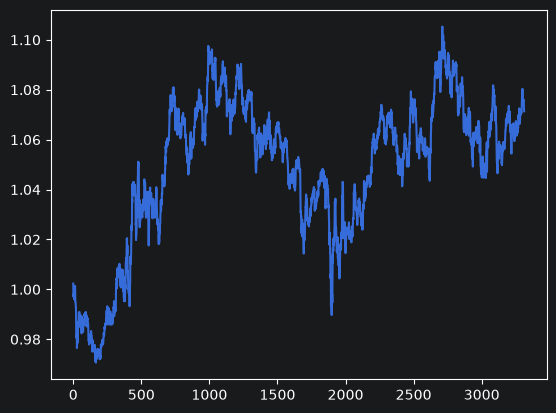

In [34]:
plt.plot(test_returns['portfolio_equity'])

timestamp,jpy_open,jpy_high,jpy_low,jpy_close,chf_open,chf_high,chf_low,chf_close,cad_open,cad_high,cad_low,cad_close,aud_open,aud_high,aud_low,aud_close,nzd_open,nzd_high,nzd_low,nzd_close,eur_open,eur_high,eur_low,eur_close,gbp_open,gbp_high,gbp_low,gbp_close
"datetime[ns, UTC]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2000-03-03 00:00:00 UTC,0.00927,0.009316,0.009256,0.009283,0.601287,0.60241,0.597015,0.598086,0.686342,0.689465,0.685871,0.68975,0.6069,0.6103,0.6054,0.6083,0.4872,0.4925,0.4871,0.489,0.9648,0.9677,0.958,0.9577,1.5769,1.584,1.5754,1.5778
2000-03-04 00:00:00 UTC,0.009283,0.009283,0.009283,0.009283,0.598086,0.598086,0.598086,0.598086,0.68975,0.68975,0.68975,0.68975,0.6083,0.6083,0.6083,0.6083,0.489,0.489,0.489,0.489,0.9577,0.9577,0.9577,0.9577,1.5778,1.5778,1.5778,1.5778
2000-03-05 00:00:00 UTC,0.009283,0.009283,0.009283,0.009283,0.598086,0.598086,0.598086,0.598086,0.68975,0.68975,0.68975,0.68975,0.6083,0.6083,0.6083,0.6083,0.489,0.489,0.489,0.489,0.9577,0.9577,0.9577,0.9577,1.5778,1.5778,1.5778,1.5778
2000-03-06 00:00:00 UTC,0.009271,0.009368,0.009266,0.009299,0.596267,0.60154,0.59538,0.596623,0.689275,0.690131,0.686342,0.688326,0.6083,0.6085,0.6012,0.602,0.4884,0.4907,0.4803,0.4826,0.9574,0.967,0.9562,0.959,1.5772,1.5823,1.5713,1.5748
2000-03-07 00:00:00 UTC,0.0093,0.009451,0.009248,0.009419,0.596481,0.598444,0.592909,0.597015,0.688279,0.689132,0.687144,0.687663,0.601,0.6059,0.601,0.6047,0.4826,0.4851,0.4815,0.484,0.9585,0.9622,0.9527,0.9581,1.5745,1.5821,1.5695,1.5796
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-12-27 00:00:00 UTC,0.006339,0.006355,0.006331,0.006339,1.112384,1.112545,1.107775,1.10882,0.693996,0.695691,0.692094,0.694054,0.62225,0.62256,0.61999,0.62146,0.56244,0.5643,0.56135,0.56232,1.04216,1.0444,1.04049,1.04225,1.25273,1.25922,1.25046,1.25714
2024-12-28 00:00:00 UTC,0.006339,0.006339,0.006339,0.006339,1.10882,1.10882,1.10882,1.10882,0.694054,0.694054,0.694054,0.694054,0.62146,0.62146,0.62146,0.62146,0.56232,0.56232,0.56232,0.56232,1.04225,1.04225,1.04225,1.04225,1.25714,1.25714,1.25714,1.25714
2024-12-29 00:00:00 UTC,0.006342,0.006343,0.006333,0.006333,1.109619,1.111,1.108783,1.108844,0.693842,0.694367,0.693727,0.694338,0.62126,0.62339,0.62105,0.62243,0.56269,0.56462,0.56243,0.56385,1.04247,1.04346,1.04247,1.04292,1.25706,1.25876,1.25615,1.25775


C:\Users\Rob\AppData\Local\Temp\ipykernel_7144\3780195013.py:141: DeprecationWarning: the `ddof` parameter for `rolling_corr` is deprecated. Correlation is invariant of `ddof`.
(Deprecated in version 1.40.0)
  pl.rolling_corr(ccy_return, peer_return, window_size=lookback, min_samples=lookback, ddof=0).alias(f"{ccy}_peer_correlation_{lookback}"),


test_rows,total_return,annualised_return,annualised_volatility,sharpe,max_drawdown
i64,f64,f64,f64,f64,f64
1301,0.093439,0.017453,0.02579,0.683799,-0.029221
